# Generate S-Matrix: Single Layer of Dielectric Cylinders

This notebook computes the **S-matrix** for a single slab of dielectric cylinders (n=1.3)
using the T-matrix multiple scattering method.

**What this example demonstrates:**
1. Setting up the physical parameters (wavelength, period, cylinder properties)
2. Placing cylinders randomly within a slab and visualizing the geometry
3. Computing the S-matrix with evanescent mode truncation
4. Extracting transmission eigenvalues via SVD of S21
5. Verifying that all $\tau^2 \leq 1$ (energy conservation)

In [1]:
import os
os.environ["JAX_ENABLE_X64"] = "1"
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp

import sys
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import svd, norm

# Add CyScat root to path
sys.path.insert(0, '../..')

from Scattering_Code.smatrix_parameters import smatrix_parameters
from Scattering_Code.jax.smatrix import smatrix
from Scattering_Code.jax.ky import ky

## 1. Physical Parameters

We use the same parameters as the MATLAB CyScat GUI defaults:
- **Wavelength** $\lambda = 0.93$
- **Period** $\Lambda = 12.81$
- **Cylinder radius** $r = 0.25$
- **Refractive index** $n = 1.3$ (dielectric), so $\varepsilon = n^2 = 1.69$
- **Normal incidence** $\phi_{inc} = \pi/2$

In [2]:
WAVELENGTH = 0.93
PERIOD     = 12.81
RADIUS     = 0.25
N_CYL_REF  = 1.3
MU         = 1.0
CMMAX      = 5
PHIINC     = np.pi / 2
Eva_TOL    = 1e-2
NUM_CYL    = 10
SEED       = 42

## 2. Compute nmax (Propagating + Evanescent Modes)

The number of Floquet modes is $2 \cdot n_{max} + 1$, where:
- $n_{prop} = \lfloor \Lambda / \lambda \rfloor$ — propagating modes
- $n_{eva}$ — evanescent modes included for accuracy (dielectric only)
- $n_{max} = n_{prop} + n_{eva}$

In [3]:
n_prop = int(np.floor(PERIOD / WAVELENGTH))
n_eva  = max(int(np.floor(
    PERIOD / (2*np.pi) * np.sqrt(
        (np.log(Eva_TOL) / (2*RADIUS))**2 + (2*np.pi/WAVELENGTH)**2
    )
)) - n_prop, 0)
nmax = n_prop + n_eva
nm = 2 * nmax + 1

print(f"n_prop = {n_prop}, n_eva = {n_eva}, nmax = {nmax}")
print(f"S-matrix size: {2*nm} x {2*nm}")

n_prop = 13, n_eva = 10, nmax = 23
S-matrix size: 94 x 94


## 3. Place Cylinders and Compute Slab Thickness

In [4]:
# Auto-compute thickness
spacing = 2.5 * RADIUS
cyls_per_row = int(PERIOD / spacing)
rows_needed = NUM_CYL / cyls_per_row + 2
thickness = round(max(0.5, rows_needed * spacing * 1.5), 1)

# Random placement with minimum separation
rng = np.random.RandomState(SEED)
margin = RADIUS * 1.5
min_sep = 2.5 * RADIUS
clocs = np.zeros((NUM_CYL, 2))

for i in range(NUM_CYL):
    for _ in range(10000):
        x = margin + rng.rand() * (PERIOD - 2*margin)
        y = margin + rng.rand() * (thickness - 2*margin)
        if i == 0 or np.all(np.sqrt((x - clocs[:i, 0])**2 + (y - clocs[:i, 1])**2) > min_sep):
            clocs[i] = [x, y]
            break

print(f"Thickness = {thickness}")
print(f"Placed {NUM_CYL} cylinders")

Thickness = 2.3
Placed 10 cylinders


## 4. Visualize Geometry

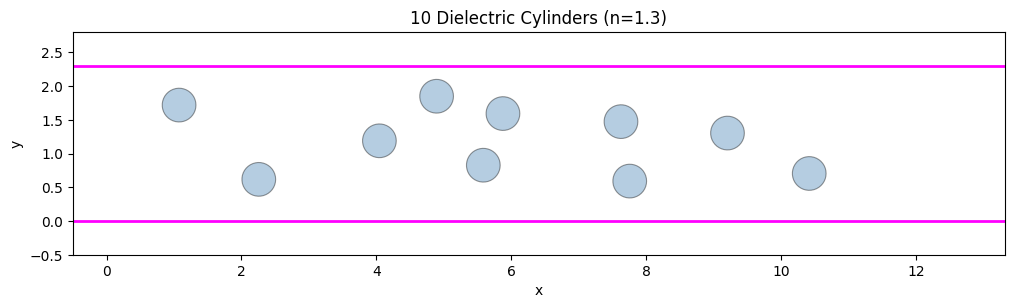

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(10, 3))
theta = np.linspace(0, 2*np.pi, 40)
for i in range(NUM_CYL):
    ax.fill(clocs[i,0] + RADIUS*np.cos(theta),
            clocs[i,1] + RADIUS*np.sin(theta),
            color='steelblue', alpha=0.4, edgecolor='black', lw=0.8)
ax.axhline(0, color='magenta', lw=2)
ax.axhline(thickness, color='magenta', lw=2)
ax.set_xlim(-0.5, PERIOD + 0.5)
ax.set_ylim(-0.5, thickness + 0.5)
ax.set_aspect('equal')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title(f'{NUM_CYL} Dielectric Cylinders (n={N_CYL_REF})')
plt.tight_layout()
plt.savefig('dielectric_geometry.png', dpi=150)
plt.show()

## 5. Compute S-Matrix

In [6]:
sp = smatrix_parameters(WAVELENGTH, PERIOD, PHIINC,
                        1e-11, 1e-4, 5, 3, 1000, 3, 5, 1, PERIOD/120)

cmmaxs = np.full(NUM_CYL, CMMAX, dtype=int)
eps_v  = N_CYL_REF**2
cepmus = np.column_stack([np.full(NUM_CYL, eps_v), np.full(NUM_CYL, MU)])
crads  = np.full(NUM_CYL, RADIUS)

print("Computing S-matrix...")
S, _ = smatrix(clocs, cmmaxs, cepmus, crads, PERIOD, WAVELENGTH, nmax, thickness, sp, 'On')
S = np.array(S)
print(f"S-matrix shape: {S.shape}")

Computing S-matrix...
  Computing T-Matrix...


W0417 23:11:38.896035 12413900 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


  transall: 45 pairs (43 spectral, 2 spatial)
  T-Matrix: 11.1s
  Solving linear system...
  Solve: 1.1s
  Computing S11 & S21...
  S11&S21: 0.7s
  Computing S12 & S22...
  S12&S22: 0.1s
  Total: 13.7s (0.2 min)
S-matrix shape: (94, 94)


## 6. Transmission Eigenvalues

The singular values of S21 (after truncating evanescent modes) give the
transmission eigenvalues $\tau$. For a lossless dielectric, all $\tau^2 \leq 1$.

In [7]:
S11 = S[:nm, :nm]
S21 = S[nm:, :nm]

# Truncate evanescent modes
if n_eva > 0:
    S21T = S21[n_eva:-n_eva, n_eva:-n_eva]
else:
    S21T = S21

tau = svd(S21T, compute_uv=False)

print(f"Number of propagating channels: {S21T.shape[0]}")
print(f"max(tau^2) = {np.max(tau**2):.6f}")
print(f"sum(tau^2) = {np.sum(tau**2):.4f}")

Number of propagating channels: 27
max(tau^2) = 1.000762
sum(tau^2) = 24.5682


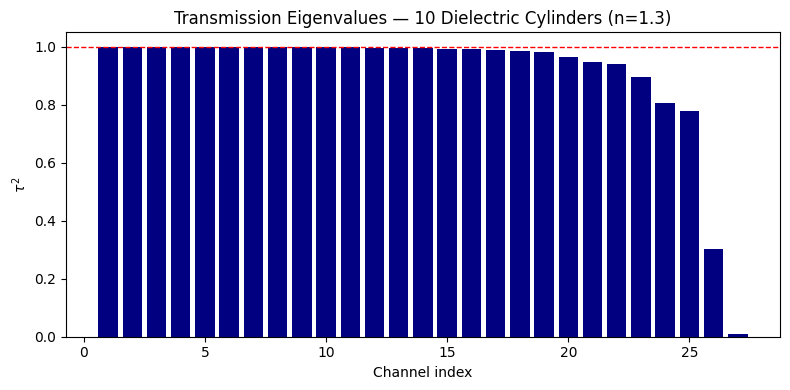

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(1, len(tau)+1), tau**2, color='navy')
ax.axhline(1.0, color='red', ls='--', lw=1)
ax.set_xlabel('Channel index')
ax.set_ylabel(r'$\tau^2$')
ax.set_title(f'Transmission Eigenvalues — {NUM_CYL} Dielectric Cylinders (n={N_CYL_REF})')
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig('dielectric_singular_values.png', dpi=150)
plt.show()